parallelization.avif

In [1]:
! pip install -qU langchain-nvidia-ai-endpoints typing_extensions langgraph IPython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.8/627.8 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 9.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.14.1 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


### **Student Report Generator**

In [33]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


class State(TypedDict):
    name: str
    grade: float
    evaluation: str
    motivation: str
    recommendation: str
    report: str

In [30]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA
import os

llm = ChatNVIDIA(model="openai/gpt-oss-20b",api_key=os.gentenv('LLM_API'))

In [20]:
def grade_evaluator(state: State):
    """Evaluate student's grade"""

    msg = llm.invoke(
        f"""
        Student Name: {state['name']}
        Grade: {state['grade']}/20

        Evaluate the student's performance in 2-3 sentences.
        """
    )

    return {"evaluation": msg.content}

In [21]:
def motivation_generator(state: State):
    """Generate motivational message"""

    msg = llm.invoke(
        f"""
        Student Name: {state['name']}
        Grade: {state['grade']}/20

        Write a short motivational message for this student.
        """
    )

    return {"motivation": msg.content}

In [22]:
def recommendation_generator(state: State):
    """Generate study recommendations"""

    msg = llm.invoke(
        f"""
        Student Name: {state['name']}
        Grade: {state['grade']}/20

        Give 3 practical study recommendations.
        """
    )

    return {"recommendation": msg.content}

In [23]:
def aggregator(state: State):
    """Generate a professional final report"""

    msg = llm.invoke(
        f"""
        Create a professional student report using:

        Evaluation:
        {state['evaluation']}

        Motivation:
        {state['motivation']}

        Recommendations:
        {state['recommendation']}

        Format it clearly with sections and a final summary.
        """
    )

    return {"report": msg.content}

In [35]:
workflow_builder = StateGraph(State)

workflow_builder.add_node("grade_evaluator",grade_evaluator)
workflow_builder.add_node("motivation_generator",motivation_generator)
workflow_builder.add_node("recommendation_generator",recommendation_generator)
workflow_builder.add_node("aggregator",aggregator)

workflow_builder.add_edge(START, "grade_evaluator")
workflow_builder.add_edge(START, "motivation_generator")
workflow_builder.add_edge(START, "recommendation_generator")

workflow_builder.add_edge("grade_evaluator", "aggregator")
workflow_builder.add_edge("motivation_generator", "aggregator")
workflow_builder.add_edge("recommendation_generator", "aggregator")
workflow_builder.add_edge("aggregator", END)

workflow = workflow_builder.compile()


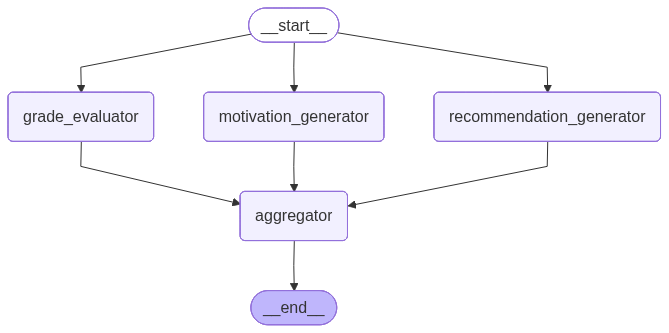

In [25]:
display(Image(workflow.get_graph().draw_mermaid_png()))

In [36]:
input_data = {
    "name": "Ahmed",
    "grade": 14.5
}

state = workflow.invoke(input_data)

print(state['report'])

# Student Performance Report – Ahmed  
**Course:** Advanced Mathematics (Mid‑Semester Review)  
**Date:** 23 June 2026  

---

## 1. Evaluation

| • | Observation |
|---|--------------|
| **Overall Score** | 14.5 / 20 |
| **Strengths** | • Consistent attendance and engagement.<br>• Solid grasp of foundational concepts.<br>• Demonstrated good time‑management during assessment periods. |
| **Areas for Improvement** | • Complex problem‑solving (e.g., multi‑step algebraic proofs).<br>• Application of theoretical concepts to real‑world scenarios.<br>• Consistency in applying test‑taking strategies (e.g., eliminating answer choices, time allocation). |
| **Conclusion** | Ahmed shows clear potential and is on an upward trajectory. Focused, structured study will elevate comprehension and elevate his score closer to full marks.  

---

## 2. Motivation

> **Hey Ahmed,**  
> 
> You’ve already nailed a solid 14.5 out of 20— that’s more than three‑quarters of the way there! Every point you earn is